In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets, layers, models
import numpy as np

C:\Users\yasrm\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
from tensorflow import keras
import os

model_loaded = None
if os.path.exists('cnn_model.h5'):
    model_loaded = keras.models.load_model('cnn_model.h5')
else:
    print('No saved model found - a new one will be trained')

No saved model found - a new one will be trained


In [3]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

C:\Users\yasrm\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()


In [4]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
print('x_train shape: ',x_train.shape)
print('x_train test: ',x_test.shape)

x_train shape:  (50000, 32, 32, 3)
x_train test:  (10000, 32, 32, 3)


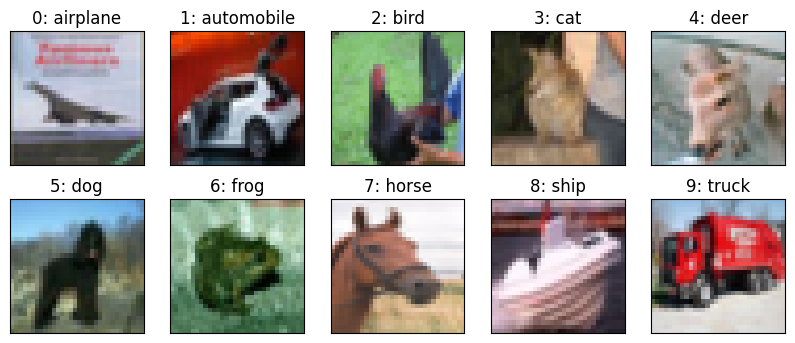

In [5]:
import matplotlib.pyplot as plt
import numpy as np
(_, _), (_, labels) = cifar10.load_data()
idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]
clsmap = {
    0:'airplane',
    1:'automobile',
    2:'bird',
    3:'cat',
    4: 'deer',
    5: 'dog',
    6:'frog',
    7:'horse',
    8:'ship',
    9:'truck'
}
plt.figure(figsize = (10,4))
for i, (img, y) in enumerate(zip(x_test[idx].reshape(10,32,32,3), labels[idx])):
  plt.subplot(2,5,i+1)
  plt.imshow(img,cmap='gray')
  plt.xticks([])
  plt.yticks([])
  plt.title(str(y[0]) + ": "+ clsmap[y[0]])
plt.show()

In [6]:
model1 = models.Sequential()


In [7]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

#dimensionality of input and latent encoded representations
inpt_dim = (32,32,3)
inpt_img= Input(shape=inpt_dim)
#Convolutional layer
c11 = Conv2D(64,(9,9), strides=(2,2), input_shape = inpt_dim, activation='relu')(inpt_img)
#Pooling and BatchNorm
p12 = MaxPooling2D(pool_size = (2,2))(c11)
bn13 = BatchNormalization()(p12)

# Add a second convolutional layer
c14 = Conv2D(128,(3,3), strides=(1,1), activation='relu')(bn13)
p15 = MaxPooling2D(pool_size = (2,2))(c14)
bn16 = BatchNormalization()(p15)

# Flattening for compatibility
f17 = Flatten()(bn16)
#Dense layers+ Dropout
do18 = Dropout(0.5)(f17)
d19 = Dense(units = 256,activation = 'relu')(do18)
do110 = Dropout(0.2)(d19)
d111 = Dense(units = 64, activation = 'relu')(do110)
do112 = Dropout(0.1)(d111)
output= Dense(units = 10, activation='sigmoid')(do112)

classifier = Model(inpt_img, output)

C:\Users\yasrm\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
opt = RMSprop(learning_rate=0.001)
classifier.compile(optimizer=opt, loss='binary_crossentropy',metrics=['accuracy'])
print(classifier.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 12, 12, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,666 (932.29 KB)

 Trainable params: 238,282 (930.79 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [9]:
# Fitting the CNN to the images
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, 
                              min_delta=1e-4, mode='min', verbose=1)

stop_alg = EarlyStopping(monitor='val_loss', patience=35, 
                         restore_best_weights=True, verbose=1)

checkpoint_filepath = 'cnn_model.h5'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

hist = classifier.fit(x_train, y_train, batch_size=512, epochs=10, 
                   callbacks=[stop_alg, reduce_lr, model_checkpoint], shuffle=True, 
                   validation_data=(x_test, y_test))


Epoch 1/10


 1/98 ━━━━━━━━━━━━━━━━━━━━ 1:44 1s/step - accuracy: 0.1270 - loss: 0.9796

 4/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.1406 - loss: 0.6251

 6/98 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1471 - loss: 0.5470

 8/98 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1580 - loss: 0.5017

...

93/98 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6031 - loss: 0.1811

95/98 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6029 - loss: 0.1811

97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6029 - loss: 0.1811

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6027 - loss: 0.1811 - val_accuracy: 0.5189 - val_loss: 0.2322 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 7.


In [10]:
classifier.save_weights("cnn1.weights.h5")


In [11]:
classifier.load_weights('cnn1.weights.h5')

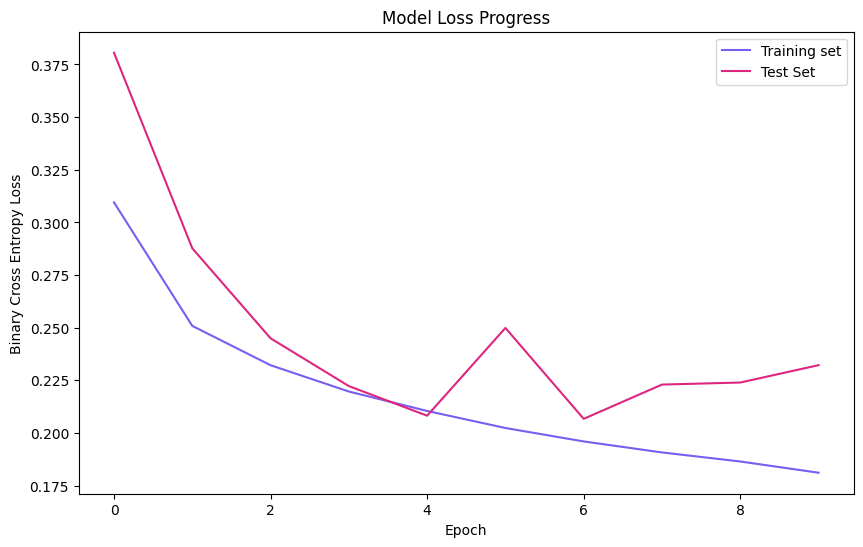

In [12]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0')
plt.plot(hist.history['val_loss'], color='#dc267f')
plt.title('Model Loss Progress')
plt.ylabel('Binary Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(['Training set','Test Set'], loc='upper right')
plt.show()

In [13]:
# from tensorflow.keras.models import load_model

# classifier = load_model('ccn_model.h5')
# classifier = load_model('cnn.hdf5')

if os.path.exists('cnn.hdf5'):
    classifier.load_weights('cnn.hdf5')
    classifier.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])
    print('Loaded pre-trained weights from cnn.hdf5')
else:
    print('No saved weights found - using the freshly trained model')

No saved weights found - using the freshly trained model


In [14]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import numpy as np
(_, _),(_, labels) = cifar10.load_data()
y_ = labels
y_hat = classifier.predict(x_test)
y_pred = np.argmax(y_hat, axis=1)

print(classification_report(np.argmax(y_test,axis=1), np.argmax(y_hat, axis=1), labels=[0,1,2,3,4,5,6,7,8,9]))

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_hat, axis=1), labels=[0,1,2,3,4,5,6,7,8,9])
print(cm)

ber = 1-balanced_accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hat, axis=1))
print('BER', ber)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step

 36/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

 74/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

111/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

150/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...

263/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

302/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


              precision    recall  f1-score   support

           0       0.55      0.61      0.58      1000
           1       0.61      0.78      0.68      1000
           2       0.33      0.62      0.43      1000
           3       0.43      0.36      0.39      1000
           4       0.63      0.29      0.40      1000
           5       0.62      0.31      0.41      1000
           6       0.81      0.47      0.59      1000
           7       0.68      0.62      0.65      1000
           8       0.47      0.90      0.62      1000
           9       0.73      0.42      0.53      1000

    accuracy                           0.54     10000
   macro avg       0.59      0.54      0.53     10000
weighted avg       0.59      0.54      0.53     10000

[[607  39  70   7   3   1   6   5 250  12]
 [ 41 775   3   6   2   2   4   2 131  34]
 [112  24 619  61  28  24  27  32  62  11]
 [ 51  31 254 356  29  82  27  44 101  25]
 [ 70  27 331  49 294  11  22  99  88   9]
 [ 32  24 232 222  22 309 

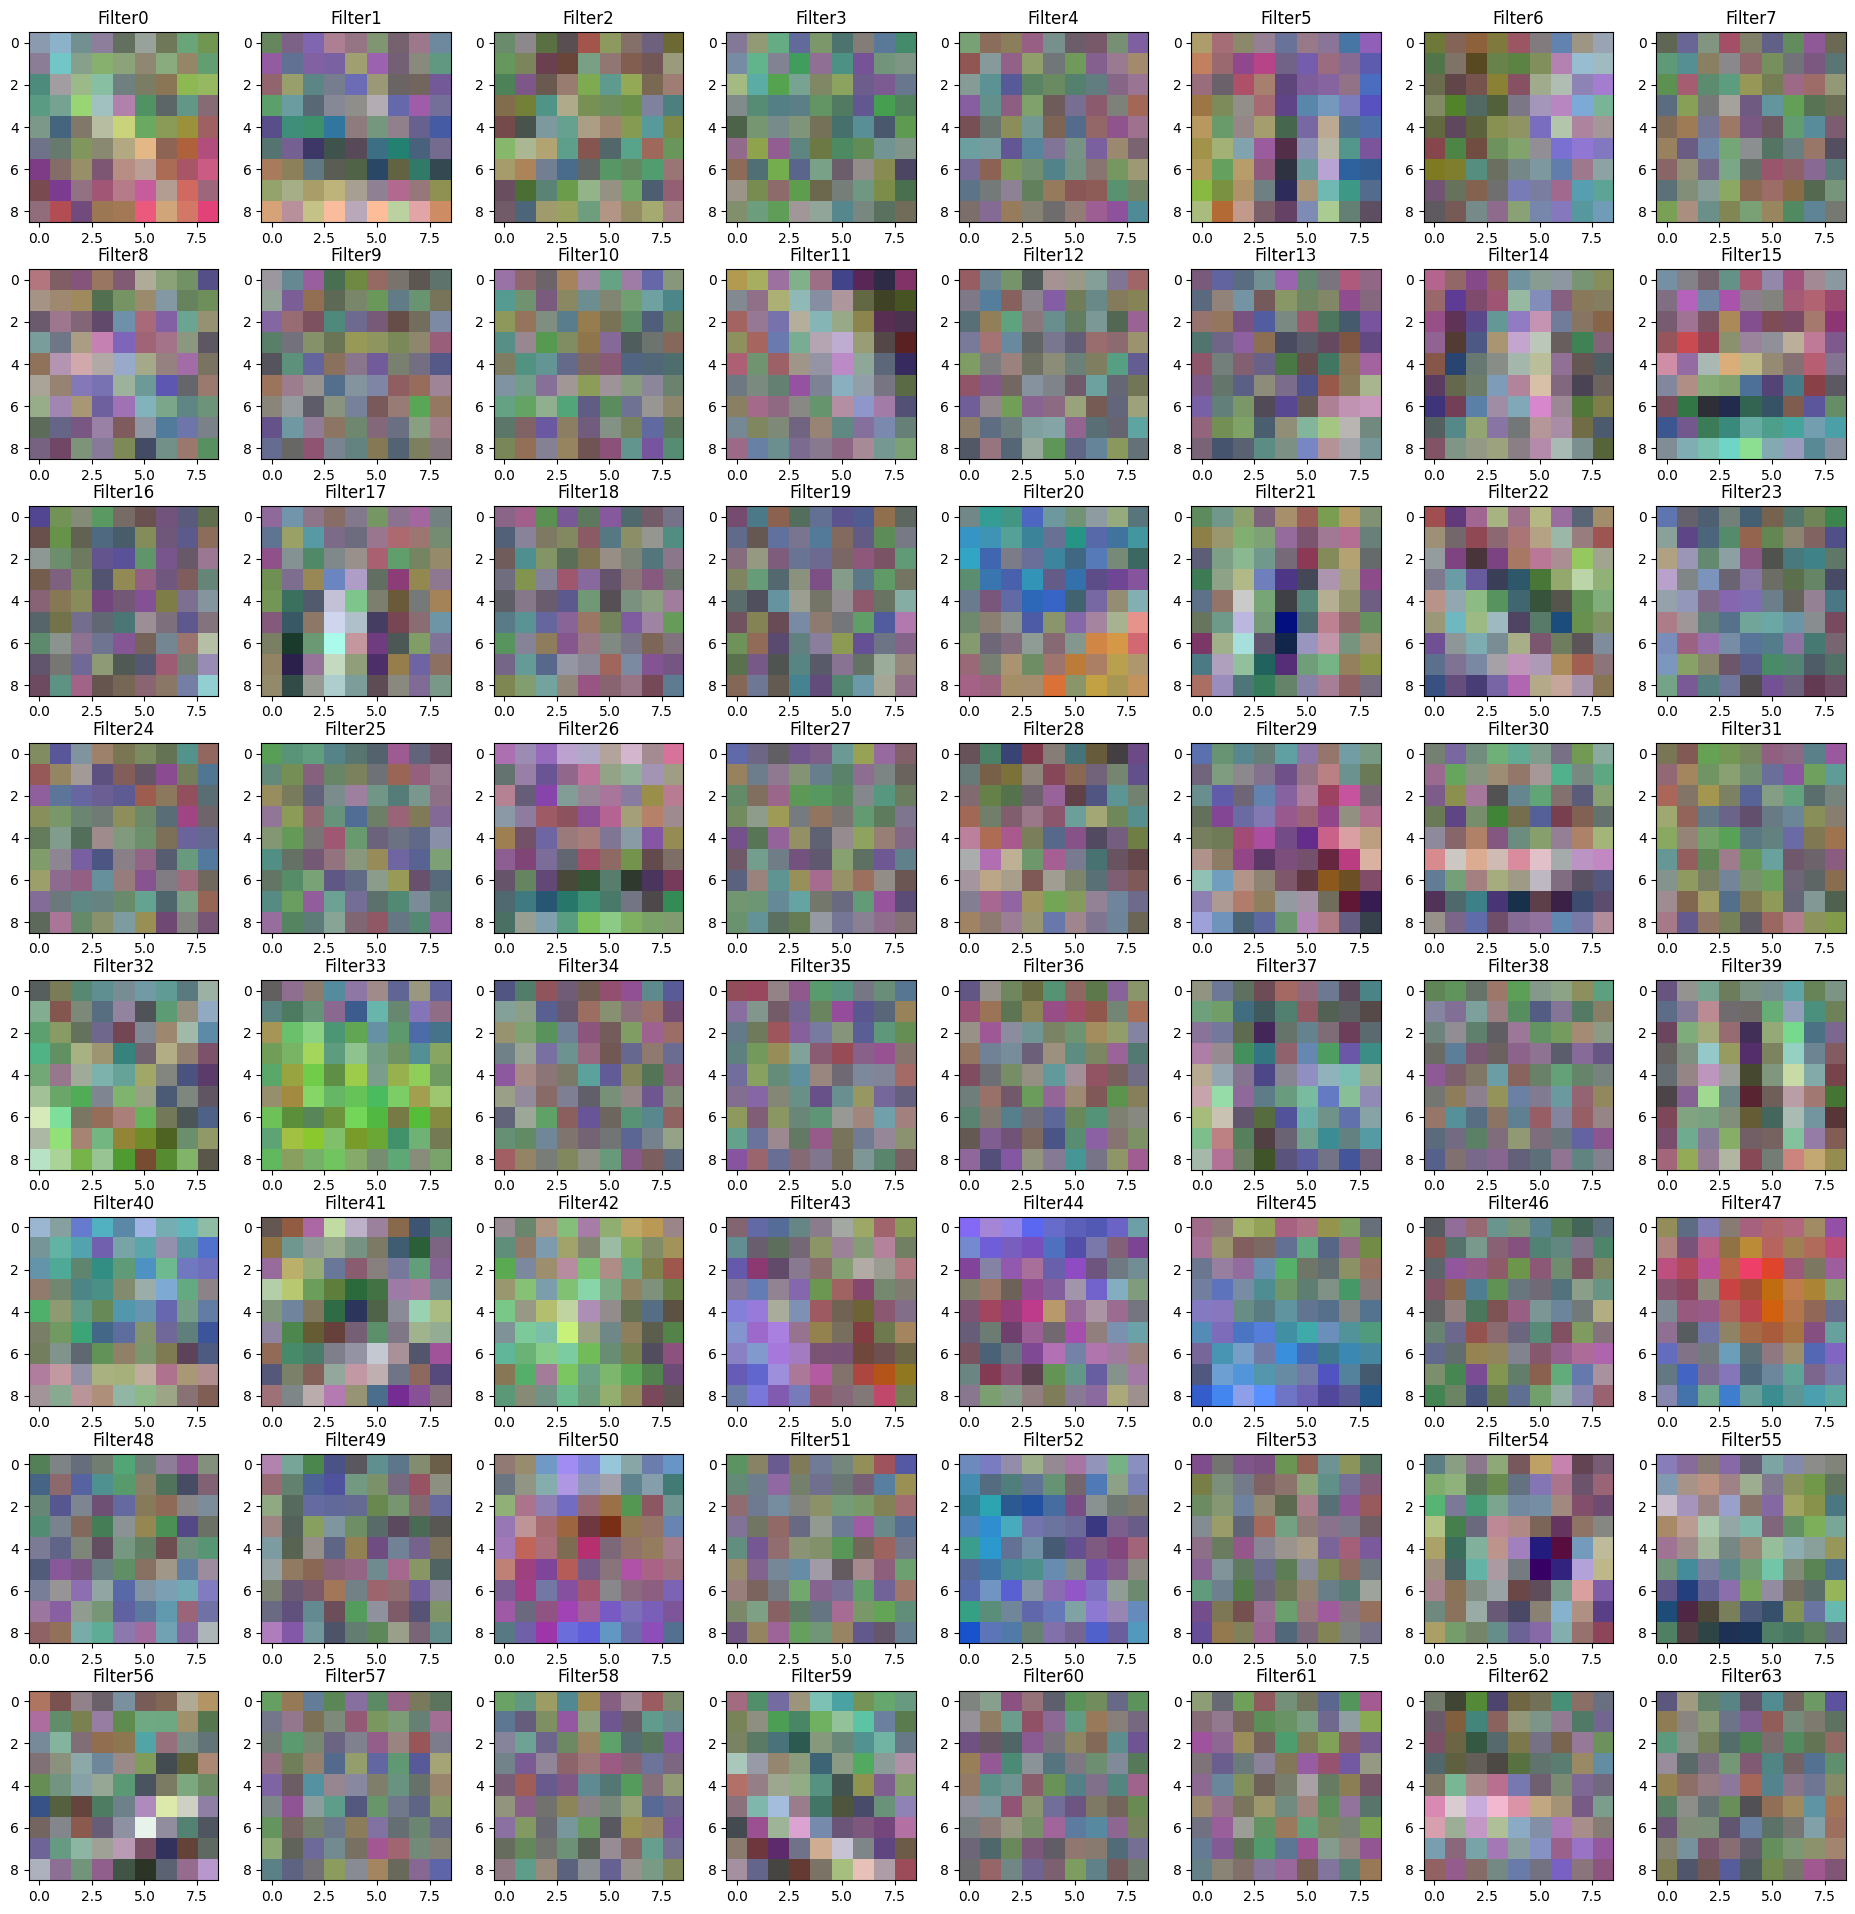

In [15]:
from sklearn.preprocessing import MinMaxScaler
cnn11 = classifier.layers[1].name # get the name of the 1st convolutional layer
w =classifier.get_layer(name=cnn11).get_weights()[0] # get the filters
wshape = w.shape # save the original shape
# we will scale to [0,1] for visualization purposes
scaler = MinMaxScaler()
scaler.fit(w.reshape(-1,1))
w = scaler.transform(w.reshape(-1,1))
w = w.reshape(wshape)
# we will display them 8x8
fig,axs = plt.subplots(8,8,figsize=(24,24))
fig.subplots_adjust(hspace=.25, wspace=.001)
axs = axs.ravel()
for i in range(w.shape[-1]):
  #we will reshape to a 3D (RGB) image shape and display
  h=np.reshape(w[:,:,:,i],(9,9,3))
  axs[i].imshow(h)
  axs[i].set_title('Filter'+str(i))

Gabor filters